In [1]:
import pandas as pd

# 1. Load the dataset (Replace the path with the one you found above)
path = '/kaggle/input/career-anxiety-due-to-ai/Career Anxiety In The Age of Artificial Intelligence - Sheet1.csv'
df = pd.read_csv(path)

# 2. Show the first 5 rows
df.head()

,participant_id,university,department,age,gender,academic_year,ai_knowledge,ai_tools_used,career_path,ai_tool_perception,ai_future_perspective,ai_replace_jobs,ai_takeover_time,career_anxiety,consent
0,P0001,Daffodil International University,Department of Computer Science & Engineering,24,Female,4th Year,Medium,"ChatGPT, Quiltbot, Grammarly",Researcher,I don't know for now,"I believe AI will mostly assist humans, with l...",No,Never,Low,Yes
1,P0002,Daffodil International University,Department of Nutrition & Food Engineering,22,Female,2nd Year,Medium,"ChatGPT, Google Gemini, Photomath",Researcher,Google Gemini,I think AI will replace some human jobs but al...,Partially,11–20 years,Medium,Yes
2,P0003,Daffodil International University,Department of Business Administration,22,Female,2nd Year,Low,"ChatGPT, Google Gemini, Microsoft Copilot",Project Manager,Microsoft Copilot,I think AI will replace some human jobs but al...,No,Never,No Anxiety,Yes
3,P0004,Daffodil International University,Department of Nutrition & Food Engineering,21,Female,2nd Year,Low,"ChatGPT, Google Gemini, Don’t know the name",Nutritionist,NaN,I believe AI will significantly replace human ...,Partially,21–50 years,No Anxiety,Yes
4,P0005,Daffodil International University,Department of Nutrition & Food Engineering,21,Male,2nd Year,Medium,"ChatGPT, Google Gemini, Microsoft Copilot",Researcher,ChatGPT,I strongly believe AI cannot take over human a...,No,Never,Low,Yes


In [2]:

# 1. Total data count
print(f"Dataset Shape: {df.shape}")

# 2. Unique column names
print(f"Columns: {df.columns.tolist()}")

# 3. Unique university data
print("-" * 30)
print("UNIVERSITY ANALYSIS")
print(f"Total Unique Universities: {df['university'].nunique()}")
print(df['university'].value_counts())

Dataset Shape: (3156, 15)
Columns: ['participant_id', 'university', 'department', 'age', 'gender', 'academic_year', 'ai_knowledge', 'ai_tools_used', 'career_path', 'ai_tool_perception', 'ai_future_perspective', 'ai_replace_jobs', 'ai_takeover_time', 'career_anxiety', 'consent']
------------------------------
UNIVERSITY ANALYSIS
Total Unique Universities: 5
university
Daffodil International University                      1064
American International University-Bangladesh            693
University of Dhaka                                     621
Jahangirnagar University                                566
Chittagong University of Engineering and Technology     212
Name: count, dtype: int64


**Departments**

In [3]:
# Print unique values in the Department column
df['department'].unique()


array(['Department of Computer Science & Engineering',
       'Department of Nutrition & Food Engineering',
       'Department of Business Administration',
       'Department of Software Engineering',
       'Department of Electrical & Electronic Engineering',
       'Department of Information and Communication Engineering',
       'Department of English', 'Department of Textile Engineering',
       'Department of Accounting',
       'Department of Innovation & Entrepreneurship',
       'Department of Genetic Engineering and Biotechnology',
       'Department of Pharmacy', 'Department of Management',
       'Department of Computer Science',
       'Institute of Nutrition and Food Science',
       'Department of Business Economics',
       'Department of Computer Science and Engineering',
       'Department of Accounting and Information Systems',
       'Department of Finance and Banking',
       'Department of Electronics & Telecommunication Engineering',
       'Department of Innovati

**Age Distribution**

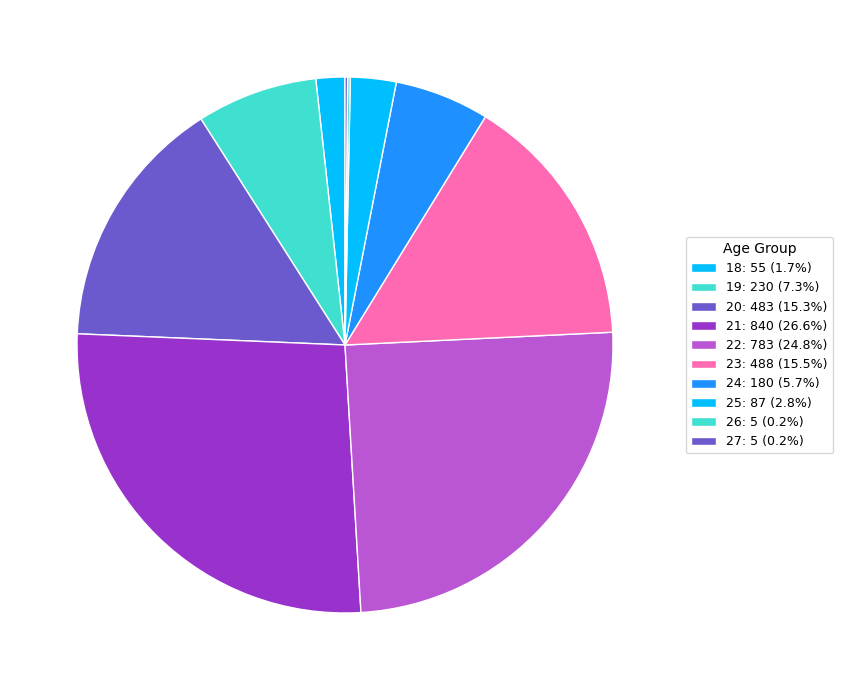

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare the data
# Count occurrences of each age and sort by age index
age_counts = df['age'].value_counts().sort_index()
total = len(df)

# 2. Create labels for the legend in the format: "Age: Count (Percentage%)"
labels = [f'{age}: {count} ({(count/total)*100:.1f}%)' 
          for age, count in age_counts.items()]

# 3. Define the colors to match the sample (blues, purples, pinks)
colors = ['#00bfff', '#40e0d0', '#6a5acd', '#9932cc', '#ba55d3', '#ff69b4', '#1e90ff', '#00bfff', '#40e0d0', '#6a5acd']

# 4. Create the plot
fig, ax = plt.subplots(figsize=(10, 7))

# Create the pie chart
# wedgeprops={'edgecolor': 'white'} adds the thin white lines between slices
wedges, _ = ax.pie(age_counts, 
                   colors=colors[:len(age_counts)], 
                   startangle=90, 
                   wedgeprops={'edgecolor': 'white', 'linewidth': 1})

# Add the legend to the right
ax.legend(wedges, labels,
          title="Age Group",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1),
          fontsize=9,
          title_fontsize=10)


plt.tight_layout()
plt.show()

***Gender Distribution***

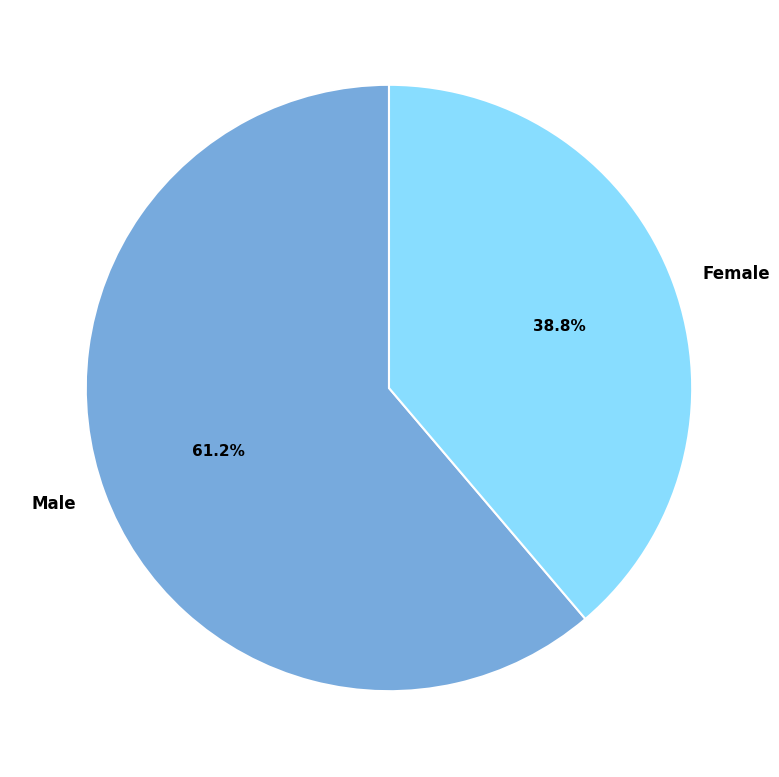

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare the data
gender_counts = df['gender'].value_counts()

# 2. Define the colors (Medium Blue for Male, Lighter Blue for Female)
# These hex codes match the shades in your image
colors = ['#77aadd', '#88ddff'] 

# 3. Create the visualization
plt.figure(figsize=(8, 8))

# Create the pie chart
wedges, texts, autotexts = plt.pie(
    gender_counts, 
    labels=gender_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# 4. Refine the text styles
# Make the labels outside normal weight and the percentages inside bold
for text in texts:
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(11)



plt.tight_layout()
plt.show()

**Academic Year Distribution**

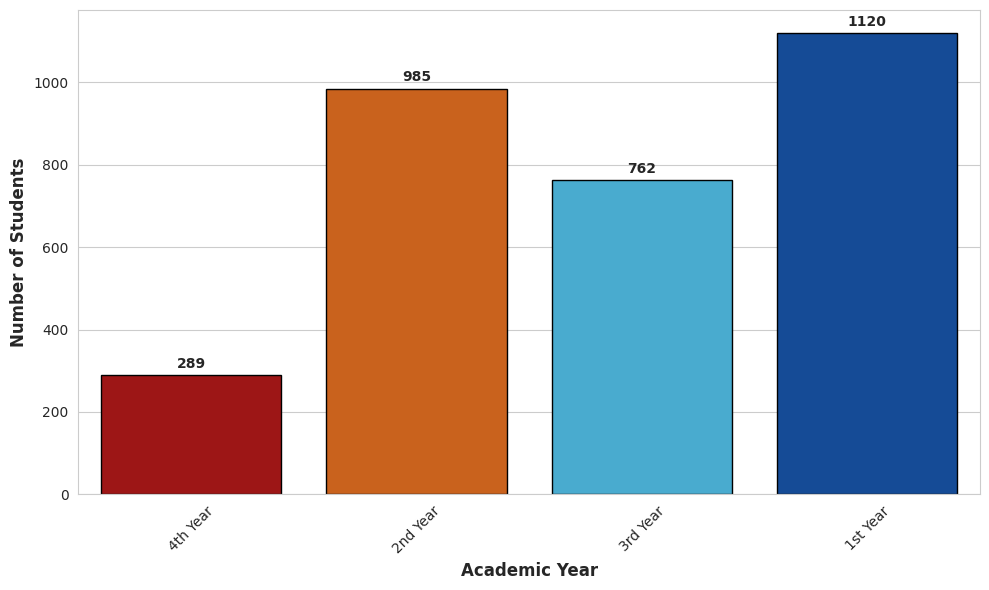

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the exact order and colors from your sample image
year_order = ['4th Year', '2nd Year', '3rd Year', '1st Year']
custom_palette = ['#b30000', '#e65c00', '#33b5e5', '#0047ab'] # Red, Orange, Sky Blue, Dark Blue

# 2. Set the figure size and style
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 3. Create the bar plot
# We map x to hue and set legend=False to avoid the common Seaborn warning
ax = sns.countplot(
    data=df, 
    x='academic_year', 
    order=year_order, 
    hue='academic_year',
    palette=custom_palette,
    edgecolor='black',
    legend=False
)

# 4. Add the data labels (numbers) on top of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=10, fontweight='bold', padding=3)

# 5. Formatting labels and titles
plt.xlabel('Academic Year', fontsize=12, fontweight='bold')
plt.ylabel('Number of Students', fontsize=12, fontweight='bold')

# Rotate X-axis labels to match the sample
plt.xticks(rotation=45)

# Clean up the grid
ax.xaxis.grid(False) # Only keep horizontal grid lines

plt.tight_layout()
plt.show()

**Department Wise Distrubution**

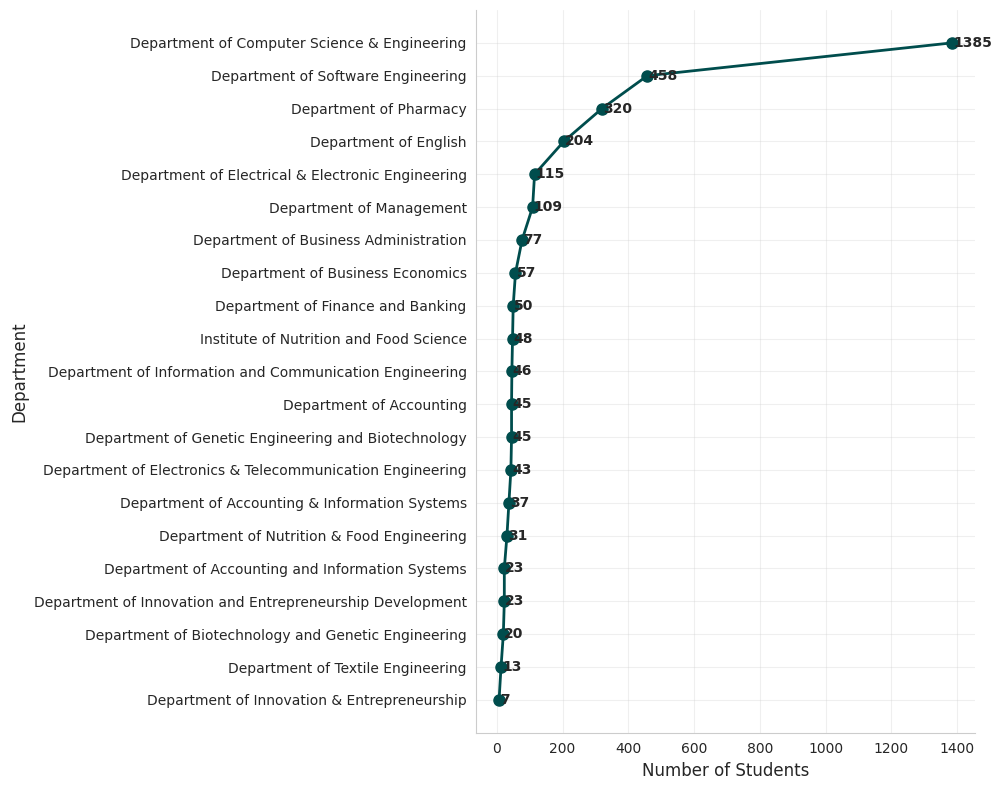

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Standardize Department names
df['department'] = df['department'].replace({
    'Department of Computer Science and Engineering': 'Department of Computer Science & Engineering',
    'Department of Computer Science': 'Department of Computer Science & Engineering'
})

# 1. Prepare the data: Count occurrences and sort so highest is at the top
dept_counts = df['department'].value_counts().reset_index()
dept_counts.columns = ['Department', 'Count']
# Sort ascending for plotting so the largest value ends up at the top of the Y-axis
dept_counts = dept_counts.sort_values(by='Count', ascending=True)

# 2. Create the plot
plt.figure(figsize=(10, 8))

# Plot the line and markers
# Color '#004d4d' is a dark teal matching your sample
plt.plot(dept_counts['Count'], dept_counts['Department'], 
         marker='o', 
         linestyle='-', 
         color='#004d4d', 
         markersize=8, 
         linewidth=2)

# 3. Add the data labels (the numbers next to the dots)
for i, row in dept_counts.iterrows():
    plt.text(row['Count'] + 3, row['Department'], str(int(row['Count'])), 
             va='center', fontsize=10, fontweight='bold')

# 4. Formatting labels and titles
plt.xlabel('Number of Students', fontsize=12)
plt.ylabel('Department', fontsize=12)

# Add a light grid for readability
plt.grid(True, linestyle='-', alpha=0.3)

# Remove top and right spines for a cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

**Usage and Perception of AI Tools**

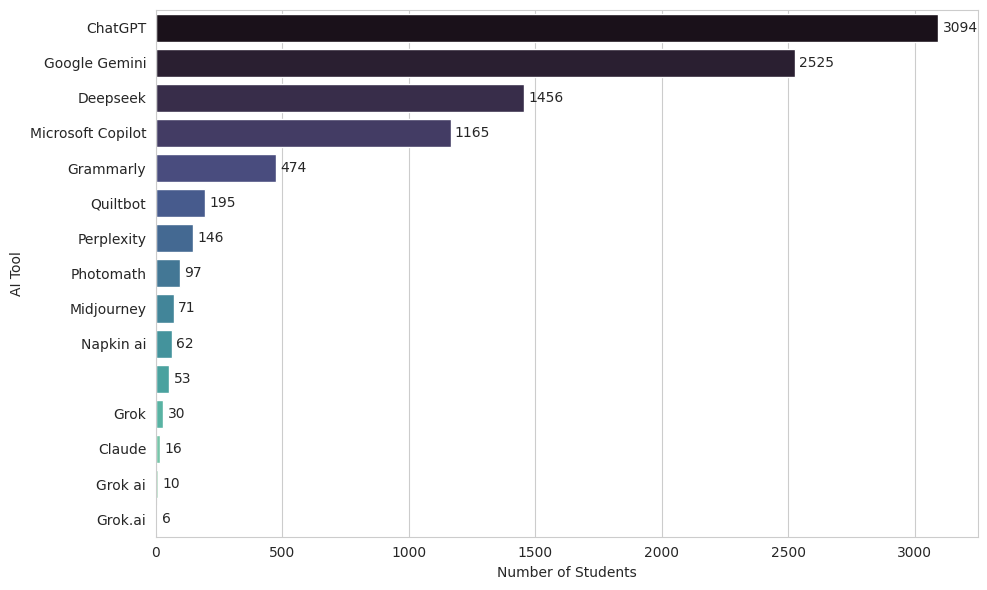

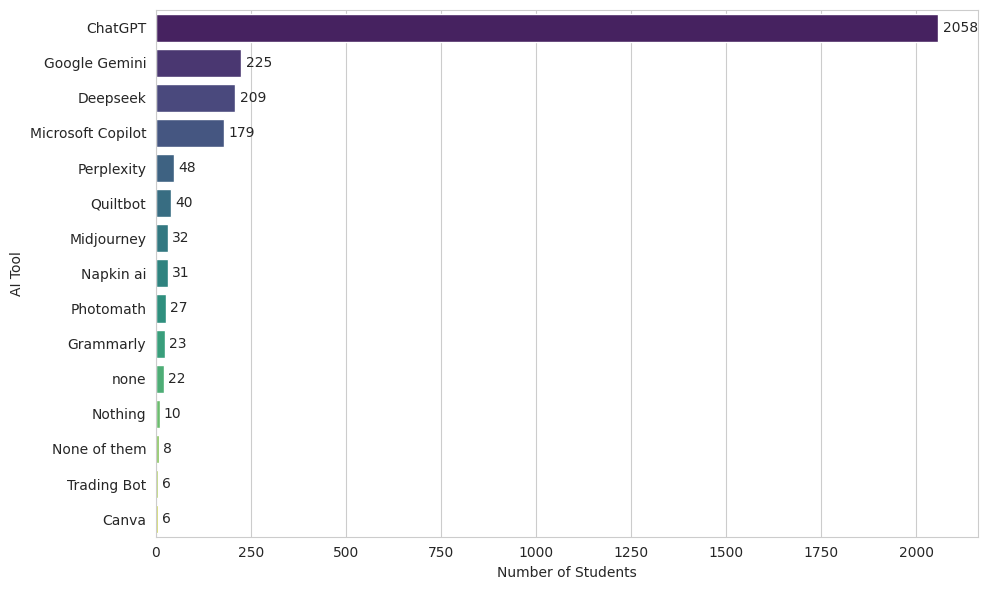

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Process Data for Graph A: Most Used AI Tools
tools_series = df['ai_tools_used'].str.split(',').explode().str.strip()
most_used_tools = tools_series.value_counts().head(15).reset_index()
most_used_tools.columns = ['AI Tool', 'Count']

# 2. Process Data for Graph B: AI Tools Perceived as Threat
threat_tools = df['ai_tool_perception'].str.strip().value_counts().head(15).reset_index()
threat_tools.columns = ['AI Tool', 'Count']

# --- FIGURE 1: Most Used AI Tools ---
plt.figure(figsize=(10, 6))
# Added hue='AI Tool' and legend=False to fix the warning
ax1 = sns.barplot(
    x='Count', 
    y='AI Tool', 
    data=most_used_tools, 
    hue='AI Tool', 
    palette='mako', 
    legend=False
)
plt.xlabel('Number of Students')
plt.ylabel('AI Tool')

for i in ax1.containers:
    ax1.bar_label(i, padding=3)

plt.tight_layout()
plt.show()

# --- FIGURE 2: AI Tools Perceived as Threat ---
plt.figure(figsize=(10, 6))
# Added hue='AI Tool' and legend=False to fix the warning
ax2 = sns.barplot(
    x='Count', 
    y='AI Tool', 
    data=threat_tools, 
    hue='AI Tool', 
    palette='viridis', 
    legend=False
)
plt.xlabel('Number of Students')
plt.ylabel('AI Tool')

for i in ax2.containers:
    ax2.bar_label(i, padding=3)

plt.tight_layout()
plt.show()

**Career Anxiety by Gender**

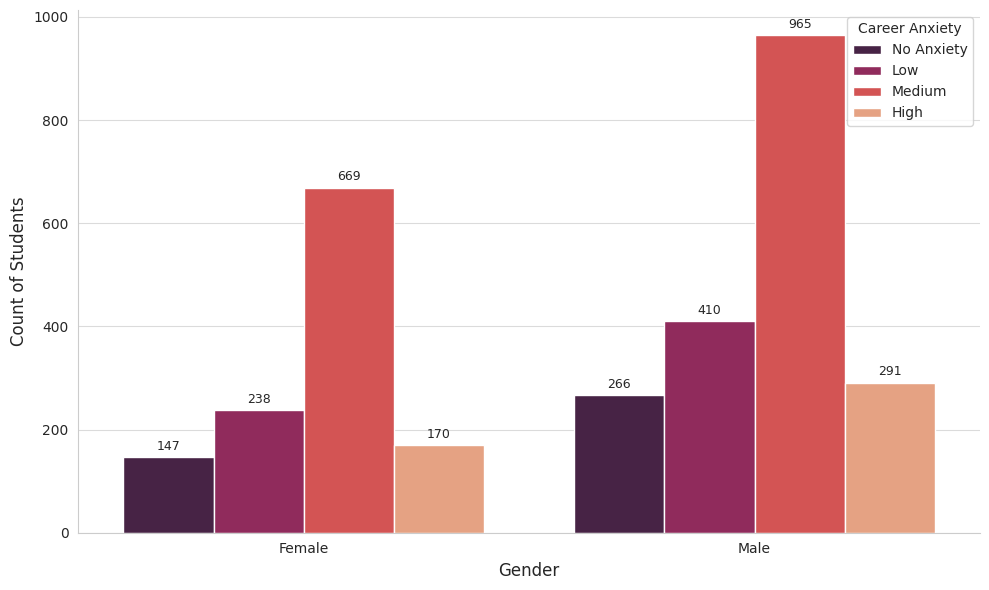

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the specific order for the anxiety levels to match the graph
anxiety_order = ['No Anxiety', 'Low', 'Medium', 'High']

# 2. Create the visualization
plt.figure(figsize=(10, 6))

# Use the 'rocket' palette for that dark-to-light red/orange look
ax = sns.countplot(
    data=df, 
    x='gender', 
    hue='career_anxiety', 
    hue_order=anxiety_order,
    palette='rocket'
)

# 3. Add formatting to match the sample
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count of Students', fontsize=12)
plt.legend(title='Career Anxiety', loc='upper right')

# Add horizontal grid lines for readability
plt.grid(axis='y', linestyle='-', alpha=0.7)
sns.despine(left=False, bottom=False) # Keep the axes lines

# 4. Add the data labels (numbers) on top of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=3)

plt.tight_layout()
plt.show()

**Career Anxiety by Academic Year**

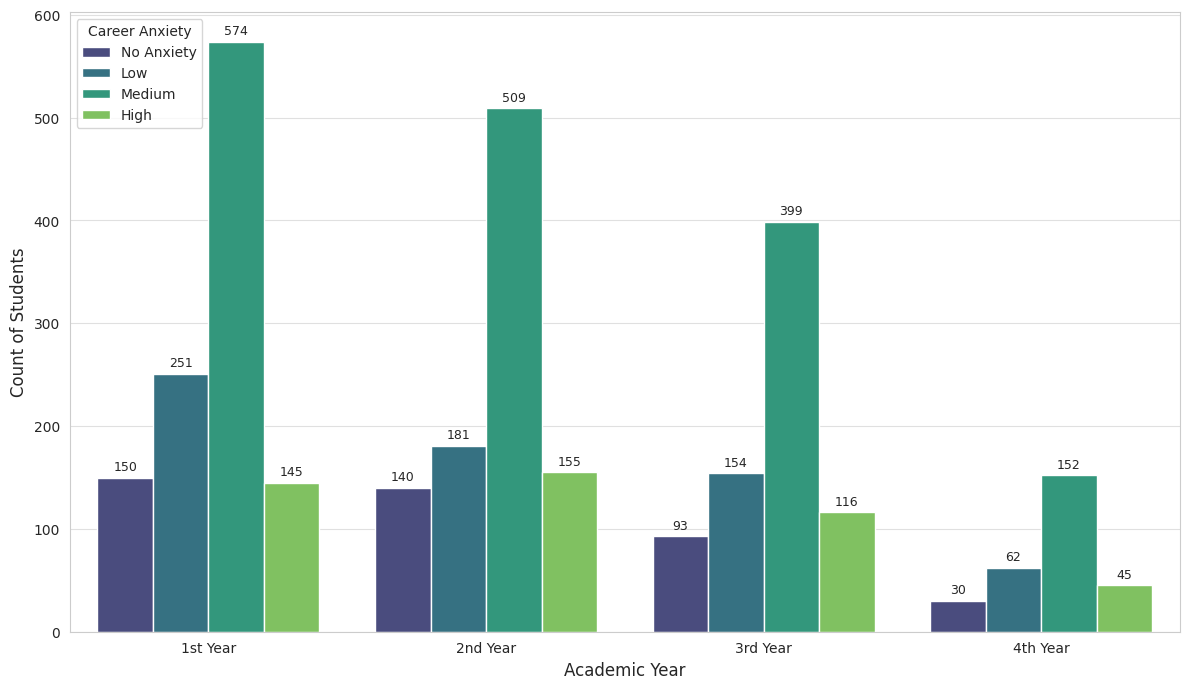

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define specific orders to ensure years and anxiety levels are sequential
year_order = ['1st Year', '2nd Year', '3rd Year', '4th Year']
anxiety_order = ['No Anxiety', 'Low', 'Medium', 'High']

# 2. Create the visualization
plt.figure(figsize=(12, 7))

# Set the style to whitegrid for the horizontal lines
sns.set_style("whitegrid")

# Use 'viridis' or 'crest' palette to match the dark blue -> green transition
ax = sns.countplot(
    data=df, 
    x='academic_year', 
    order=year_order,
    hue='career_anxiety', 
    hue_order=anxiety_order,
    palette='viridis'
)

# 3. Add formatting to match the sample image
plt.xlabel('Academic Year', fontsize=12)
plt.ylabel('Count of Students', fontsize=12)
plt.legend(title='Career Anxiety', loc='upper left')

# 4. Add the data labels (numbers) on top of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=3)

# Ensure the grid lines match the look
ax.yaxis.grid(True, linestyle='-', alpha=0.6)
ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

**Career Anxiety By Age**

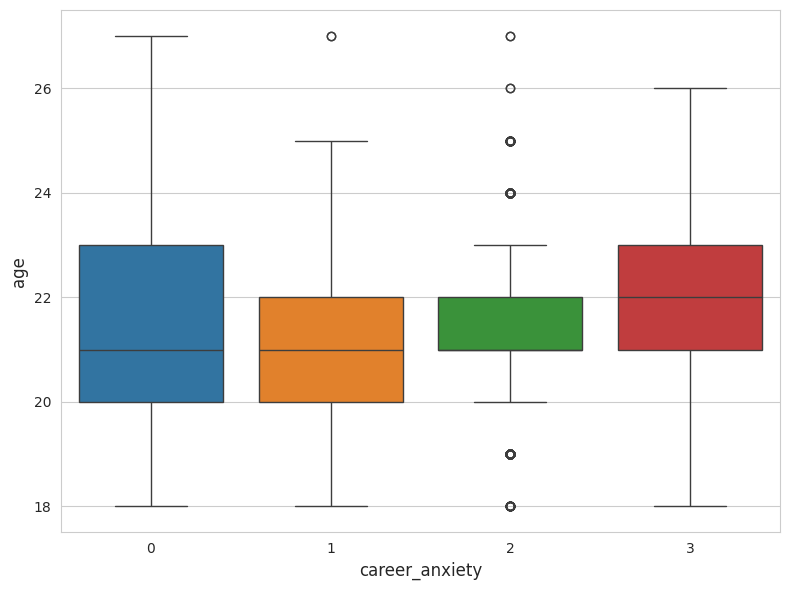

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map the text anxiety levels to numbers to match the sample image
# No Anxiety -> 0, Low -> 1, Medium -> 2, High -> 3
anxiety_map = {'No Anxiety': 0, 'Low': 1, 'Medium': 2, 'High': 3}
df['anxiety_numeric'] = df['career_anxiety'].map(anxiety_map)

# 2. Create the Boxplot
plt.figure(figsize=(8, 6))

# Use the 'tab10' palette to get the exact Blue, Orange, Green, Red colors
ax = sns.boxplot(
    data=df, 
    x='anxiety_numeric', 
    y='age', 
    hue='anxiety_numeric', # Categorizing by numeric anxiety
    palette='tab10', 
    legend=False
)

# 3. Add formatting to match the sample
plt.xlabel('career_anxiety', fontsize=12)
plt.ylabel('age', fontsize=12)

# Adjust plot limits if necessary to match the age range (18 to 27+)
plt.ylim(17.5, 27.5)

plt.tight_layout()
plt.show()

**Career Anxiety by Department**

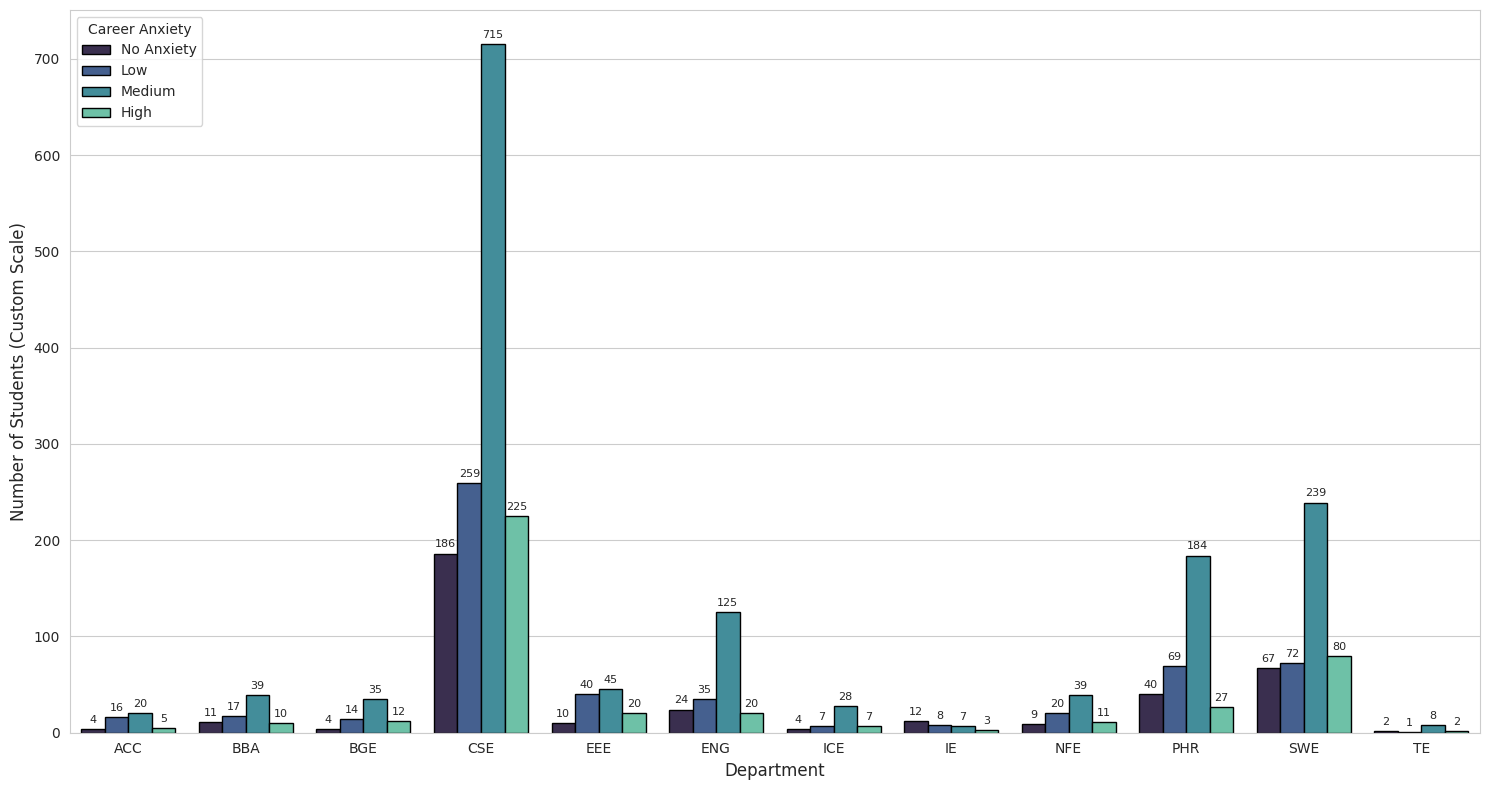

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map full department names to abbreviations to match the sample image
dept_map = {
    'Department of Accounting': 'ACC',
    'Department of Business Administration': 'BBA',
    'Department of Genetic Engineering and Biotechnology': 'BGE',
    'Department of Biotechnology and Genetic Engineering': 'BGE',
    'Department of Computer Science & Engineering': 'CSE',
    'Department of Computer Science': 'CSE',
    'Department of Electrical & Electronic Engineering': 'EEE',
    'Department of English': 'ENG',
    'Department of Information and Communication Engineering': 'ICE',
    'Department of Innovation & Entrepreneurship': 'IE',
    'Department of Innovation and Entrepreneurship Development': 'IE',
    'Department of Nutrition & Food Engineering': 'NFE',
    'Institute of Nutrition and Food Science': 'NFE',
    'Department of Pharmacy': 'PHR',
    'Department of Software Engineering': 'SWE',
    'Department of Textile Engineering': 'TE'
}

# Apply the mapping
df['dept_short'] = df['department'].map(dept_map)

# 2. Define specific orders
anxiety_order = ['No Anxiety', 'Low', 'Medium', 'High']
dept_order = sorted(df['dept_short'].dropna().unique()) # Alphabetical order

# 3. Create the visualization
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# Using 'mako' palette with black edgecolors to match the sample style
ax = sns.countplot(
    data=df, 
    x='dept_short', 
    order=dept_order,
    hue='career_anxiety', 
    hue_order=anxiety_order,
    palette='mako',
    edgecolor='black'
)

# 4. Add formatting to match the sample
plt.xlabel('Department', fontsize=12)
plt.ylabel('Number of Students (Custom Scale)', fontsize=12)
plt.legend(title='Career Anxiety', loc='upper left')

# 5. Add the data labels (numbers) on top of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=8, padding=3)

# Clean up axes and grid
ax.xaxis.grid(False)
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

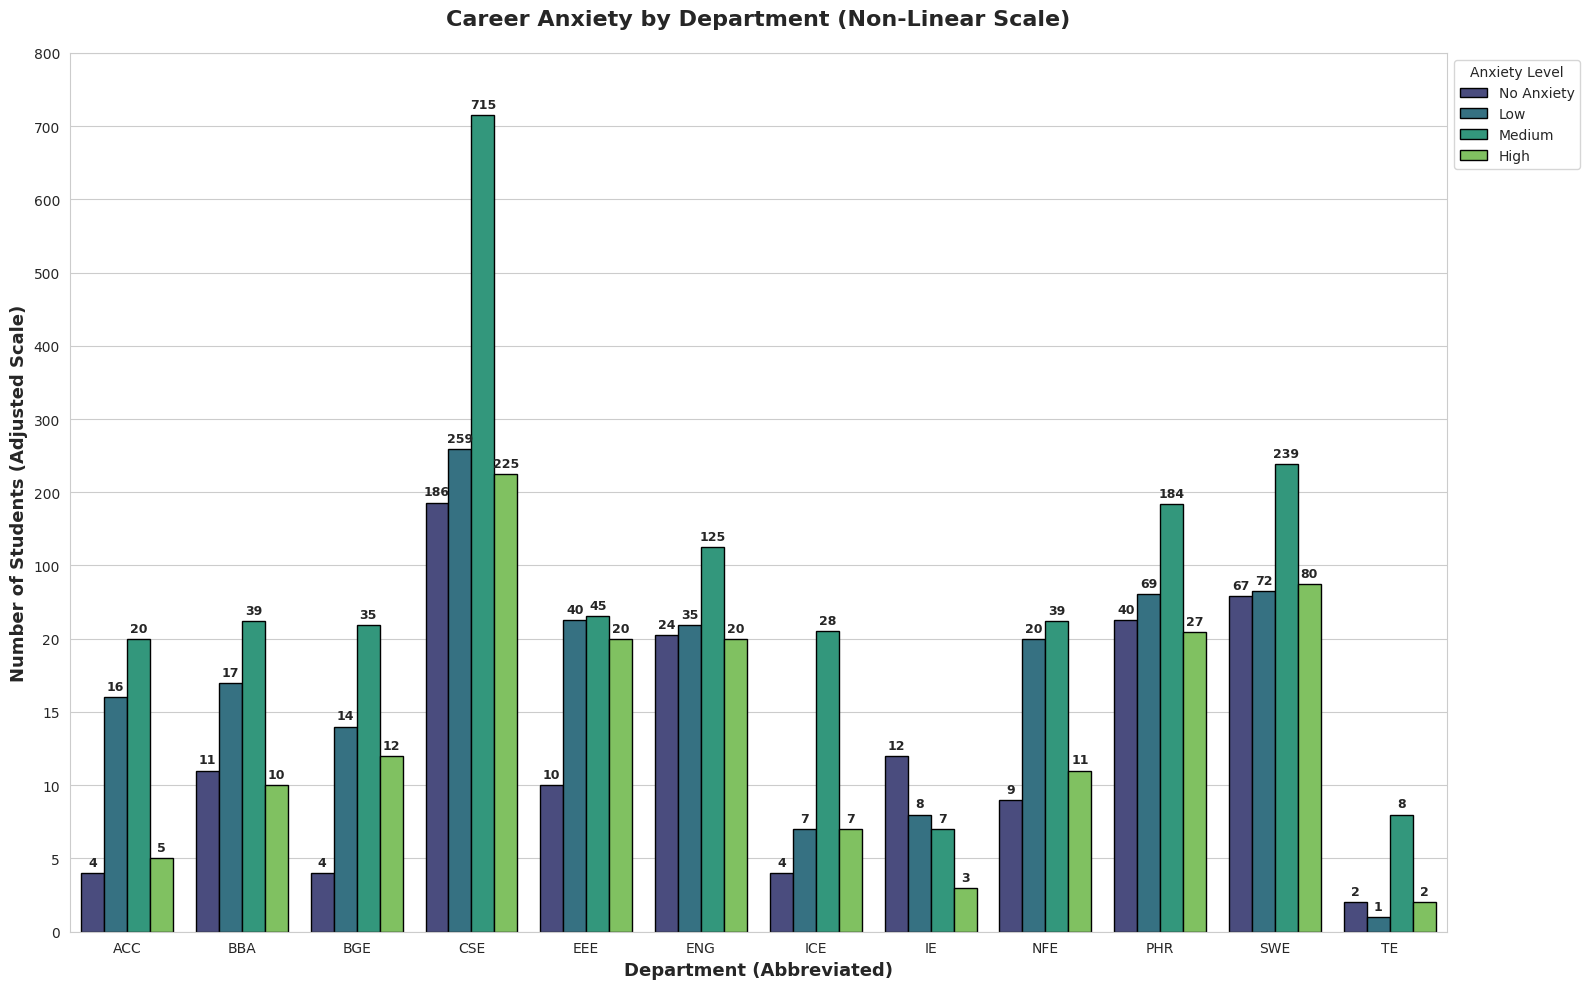

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Data Preparation & Mapping
# ---------------------------------------------------------
# Define the department abbreviations mapping
dept_map = {
    'Department of Accounting': 'ACC',
    'Department of Business Administration': 'BBA',
    'Department of Genetic Engineering and Biotechnology': 'BGE',
    'Department of Biotechnology and Genetic Engineering': 'BGE',
    'Department of Computer Science & Engineering': 'CSE',
    'Department of Computer Science': 'CSE',
    'Department of Electrical & Electronic Engineering': 'EEE',
    'Department of English': 'ENG',
    'Department of Information and Communication Engineering': 'ICE',
    'Department of Innovation & Entrepreneurship': 'IE',
    'Department of Innovation and Entrepreneurship Development': 'IE',
    'Department of Nutrition & Food Engineering': 'NFE',
    'Institute of Nutrition and Food Science': 'NFE',
    'Department of Pharmacy': 'PHR',
    'Department of Software Engineering': 'SWE',
    'Department of Textile Engineering': 'TE'
}

# Apply mappings to the dataframe
df['dept_short'] = df['department'].map(dept_map)

# Map career anxiety to numeric for sorting and calculation
anxiety_labels = {0: 'No Anxiety', 1: 'Low', 2: 'Medium', 3: 'High'}
anxiety_rev_map = {'No Anxiety': 0, 'Low': 1, 'Medium': 2, 'High': 3}
df['anxiety_numeric'] = df['career_anxiety'].map(anxiety_rev_map)

# 2. Group and Count Data
# ---------------------------------------------------------
# Filter out rows where department mapping failed
plot_data_raw = df.dropna(subset=['dept_short'])

# Group by Short Dept Name and Numeric Anxiety
anxiety_counts = plot_data_raw.groupby(['dept_short', 'anxiety_numeric']).size().reset_index(name='count')
anxiety_counts['career_anxiety_label'] = anxiety_counts['anxiety_numeric'].map(anxiety_labels)

# 3. Custom Scale Logic
# ---------------------------------------------------------
max_val = anxiety_counts['count'].max()

# Define original breakpoints (The numbers you want to see on the axis)
# Example: 0 to 20 by small steps, then 100 to Max by large steps
breaks_original = [0, 5, 10, 15, 20]
current_tick = 100
while current_tick <= max_val + 100:
    breaks_original.append(current_tick)
    current_tick += 100

# Define where these will appear on the plot (0, 1, 2, 3...)
breaks_scaled = list(range(len(breaks_original)))

def custom_transform(y):
    return np.interp(y, breaks_original, breaks_scaled)

anxiety_counts['count_scaled'] = anxiety_counts['count'].apply(custom_transform)

# 4. Create the Visualization
# ---------------------------------------------------------
plt.figure(figsize=(16, 10))
sns.set_style("whitegrid")

anxiety_order = ['No Anxiety', 'Low', 'Medium', 'High']
dept_order = sorted(anxiety_counts['dept_short'].unique())

ax = sns.barplot(
    data=anxiety_counts,
    x='dept_short',
    y='count_scaled',
    hue='career_anxiety_label',
    hue_order=anxiety_order,
    palette='viridis',
    edgecolor='black',
    order=dept_order
)

# 5. Fix Y-Axis and Labels
# ---------------------------------------------------------
# Set the y-axis ticks to the SCALED positions but label with ORIGINAL values
ax.set_yticks(breaks_scaled)
ax.set_yticklabels(breaks_original)
ax.set_ylim(0, max(breaks_scaled))

# Add the actual counts on top of bars
for i, container in enumerate(ax.containers):
    # Get current hue label being processed
    current_hue = anxiety_order[i]
    
    # Create a lookup for current hue: {Dept: Count}
    hue_subset = anxiety_counts[anxiety_counts['career_anxiety_label'] == current_hue]
    count_lookup = pd.Series(hue_subset['count'].values, index=hue_subset['dept_short']).to_dict()
    
    # Order counts correctly based on the X-axis (dept_order)
    labels = [int(count_lookup.get(dept, 0)) for dept in dept_order]
    
    # Format labels: hide 0s for a cleaner look
    final_labels = [str(v) if v > 0 else '' for v in labels]
    
    ax.bar_label(container, labels=final_labels, fontsize=9, fontweight='bold', padding=3)

# 6. Final Formatting
# ---------------------------------------------------------
plt.title('Career Anxiety by Department (Non-Linear Scale)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Department (Abbreviated)', fontsize=13, fontweight='bold')
plt.ylabel('Number of Students (Adjusted Scale)', fontsize=13, fontweight='bold')

plt.legend(title='Anxiety Level', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

# Save high-quality output
plt.savefig('department_anxiety_custom_scale.png', dpi=300, bbox_inches='tight')
plt.show()

**Career Anxiety Count By Ai Knowledge Level**

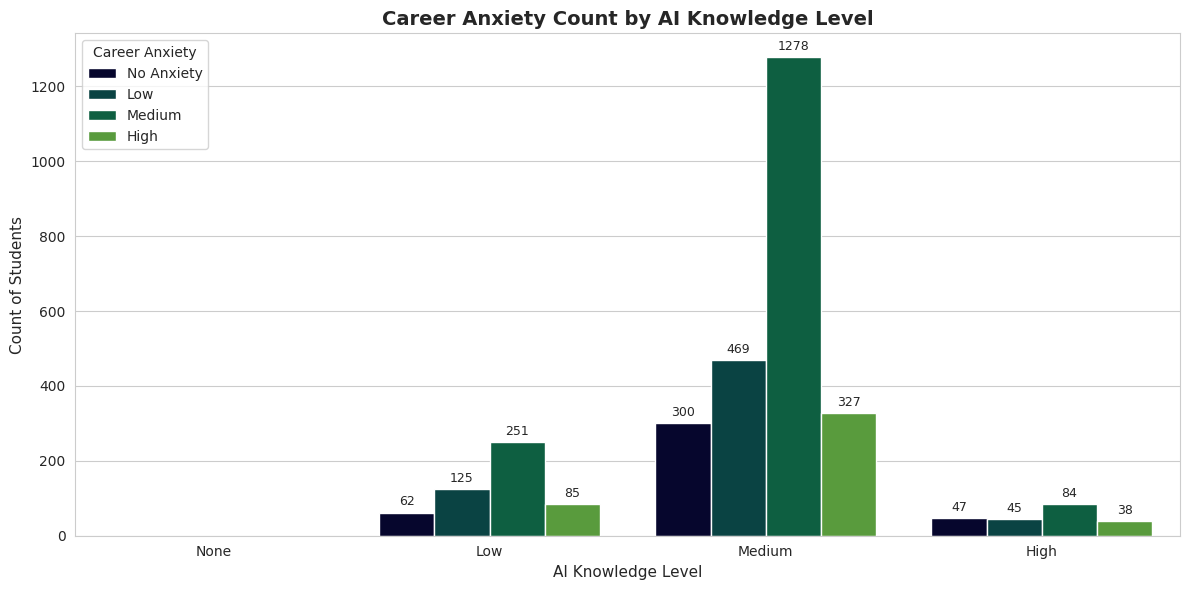

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the correct sequential orders for the axes
knowledge_order = ['None', 'Low', 'Medium', 'High']
anxiety_order = ['No Anxiety', 'Low', 'Medium', 'High']

# 2. Set the aesthetic style
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# 3. Create the grouped count plot
# We use a custom color list to match the navy-to-green gradient in your image
custom_colors = ["#000033", "#004d4d", "#006d44", "#52ab2d"]

ax = sns.countplot(
    data=df, 
    x='ai_knowledge', 
    order=knowledge_order,
    hue='career_anxiety', 
    hue_order=anxiety_order,
    palette=custom_colors,
    edgecolor='white'
)

# 4. Add formatting and labels
plt.title('Career Anxiety Count by AI Knowledge Level', fontsize=14, fontweight='bold')
plt.xlabel('AI Knowledge Level', fontsize=11)
plt.ylabel('Count of Students', fontsize=11)

# Position the legend in the upper left
plt.legend(title='Career Anxiety', loc='upper left')

# 5. Add data labels (numbers) on top of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=3)

# Final layout adjustment
plt.tight_layout()
plt.show()

**Average Anxiety level**

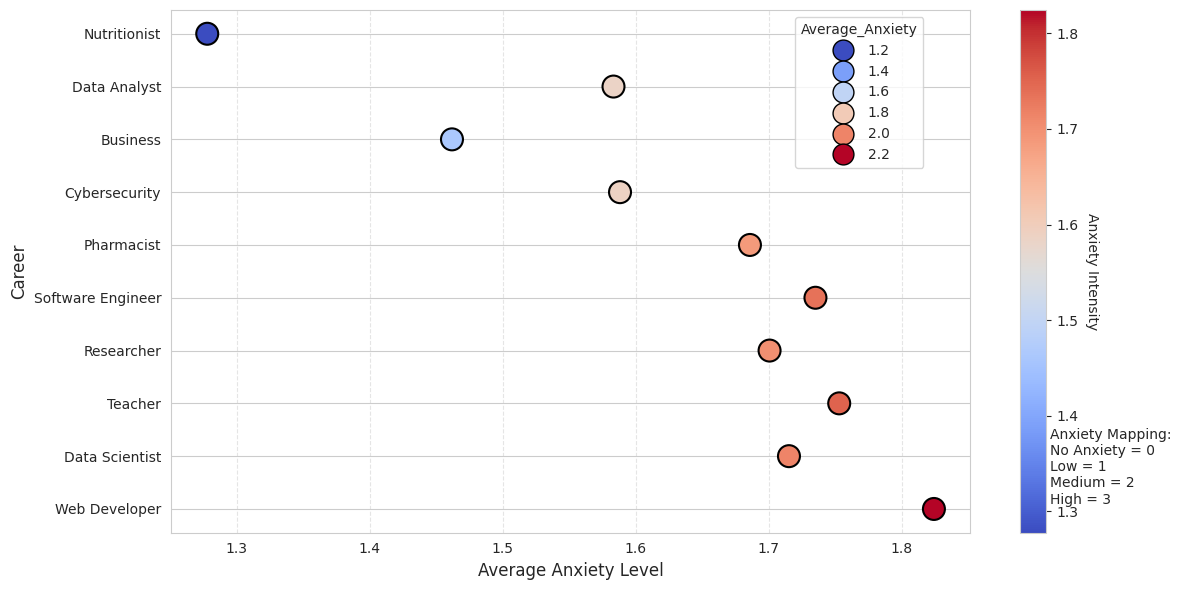

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Map Anxiety levels to numbers
anxiety_map = {'No Anxiety': 0, 'Low': 1, 'Medium': 2, 'High': 3}
df['anxiety_score'] = df['career_anxiety'].map(anxiety_map)

# 2. Categorize the messy career_path into the bins shown in the image
def categorize_career(path):
    path = str(path).lower()
    if 'nutritionist' in path: return 'Nutritionist'
    if 'analyst' in path: return 'Data Analyst'
    if any(x in path for x in ['business', 'entrepreneur', 'banker', 'accountant', 'corporate', 'manager']): return 'Business'
    if any(x in path for x in ['cyber', 'security', 'hacker']): return 'Cybersecurity'
    if 'pharmacist' in path: return 'Pharmacist'
    if 'web' in path or 'front-end' in path: return 'Web Developer'
    if 'data scientist' in path or 'ml' in path or 'ai engineer' in path: return 'Data Scientist'
    if any(x in path for x in ['teacher', 'lecturer', 'professor']): return 'Teacher'
    if 'researcher' in path or 'research' in path: return 'Researcher'
    if any(x in path for x in ['software', 'developer', 'programmer']): return 'Software Engineer'
    return 'Other'

df['career_group'] = df['career_path'].apply(categorize_career)

# 3. Calculate the Average Anxiety per career
# Filter out 'Other' and group
plot_df = df[df['career_group'] != 'Other'].groupby('career_group')['anxiety_score'].mean().reset_index()
plot_df.columns = ['Career', 'Average_Anxiety']

# Define the exact order from the image
career_order = ['Nutritionist', 'Data Analyst', 'Business', 'Cybersecurity', 'Pharmacist', 
                'Software Engineer', 'Researcher', 'Teacher', 'Data Scientist', 'Web Developer']

# Sort the dataframe to match the order
plot_df['Career'] = pd.Categorical(plot_df['Career'], categories=career_order, ordered=True)
plot_df = plot_df.sort_values('Career')

# 4. Create the Visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Scatter plot with color mapping
sc = ax.scatter(plot_df['Average_Anxiety'], plot_df['Career'], 
                c=plot_df['Average_Anxiety'], cmap='coolwarm', 
                s=250, edgecolors='black', linewidth=1.5, zorder=3)

# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Anxiety Intensity', rotation=270, labelpad=15)

# Formatting
ax.set_xlabel('Average Anxiety Level', fontsize=12)
ax.set_ylabel('Career', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.invert_yaxis() # To put Nutritionist at the top

# Add the Anxiety Mapping text box (Bottom Right)
textstr = "Anxiety Mapping:\nNo Anxiety = 0\nLow = 1\nMedium = 2\nHigh = 3"
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax.text(1.1, 0.05, textstr, transform=ax.transAxes, fontsize=10, verticalalignment='bottom', bbox=props)

# Handle the legend (Custom handles to match colors)
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label=f'{val:.1f}',
                          markerfacecolor=plt.cm.coolwarm((val-1.2)/(2.2-1.2)), 
                          markersize=15, markeredgecolor='black') 
                   for val in [1.2, 1.4, 1.6, 1.8, 2.0, 2.2]]
ax.legend(handles=legend_elements, title='Average_Anxiety', loc='upper right', bbox_to_anchor=(0.95, 1))

plt.tight_layout()
plt.show()

**Expected Time for Ai takeover**

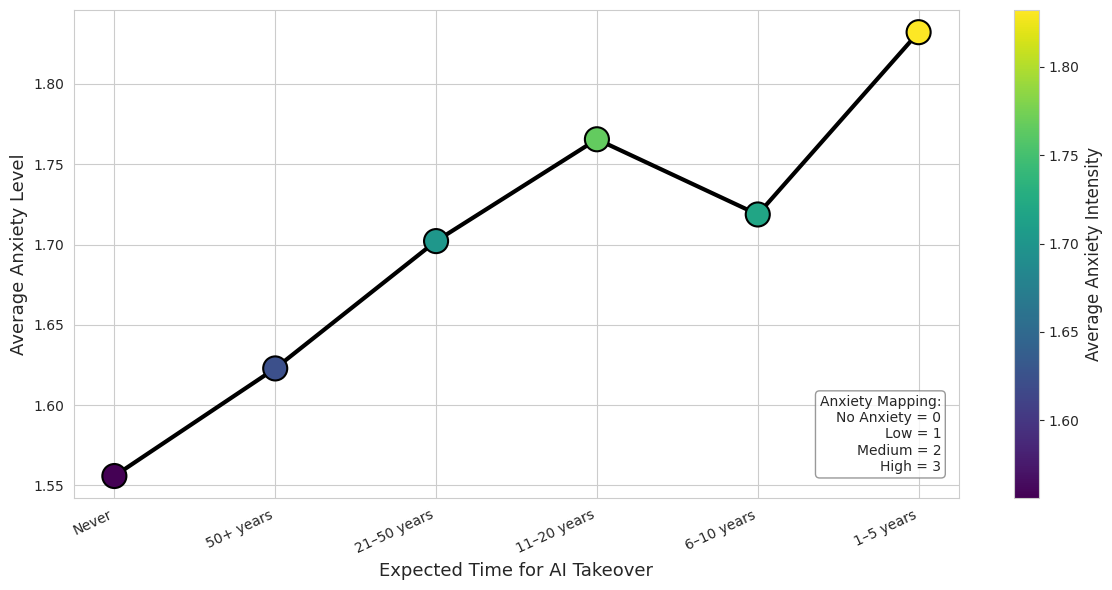

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map Anxiety levels to numeric scores
anxiety_mapping = {'No Anxiety': 0, 'Low': 1, 'Medium': 2, 'High': 3}
df['anxiety_score'] = df['career_anxiety'].map(anxiety_mapping)

# 2. Define the specific order for the X-axis (from furthest time to nearest)
time_order = ['Never', '50+ years', '21–50 years', '11–20 years', '6–10 years', '1–5 years']

# 3. Calculate the mean anxiety score for each takeover timeframe
# We group the data and reorder it based on the list above
line_df = df.groupby('ai_takeover_time')['anxiety_score'].mean().reindex(time_order).reset_index()

# 4. Create the Plot
fig, ax = plt.subplots(figsize=(12, 6))

# Set light grid style
sns.set_style("whitegrid", {'axes.grid': True, 'grid.color': '.9'})

# Plot the thick black line
ax.plot(line_df['ai_takeover_time'], line_df['anxiety_score'], 
        color='black', linewidth=3, zorder=1)

# Plot the markers using scatter so we can map colors to the values
# 'viridis' colormap matches the purple -> green -> yellow gradient
sc = ax.scatter(line_df['ai_takeover_time'], line_df['anxiety_score'], 
                c=line_df['anxiety_score'], cmap='viridis', 
                s=300, edgecolors='black', linewidth=1.5, zorder=2)

# 5. Add the Colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Average Anxiety Intensity', fontsize=12)

# 6. Add the Anxiety Mapping text box (Bottom Right)
textstr = "Anxiety Mapping:\nNo Anxiety = 0\nLow = 1\nMedium = 2\nHigh = 3"
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
ax.text(0.98, 0.05, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right', bbox=props)

# 7. Labels and Formatting
ax.set_xlabel('Expected Time for AI Takeover', fontsize=13)
ax.set_ylabel('Average Anxiety Level', fontsize=13)

# Rotate x-axis labels for better fit
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Final layout adjustments
plt.tight_layout()
plt.show()

**Ai Tools as Threat across career**

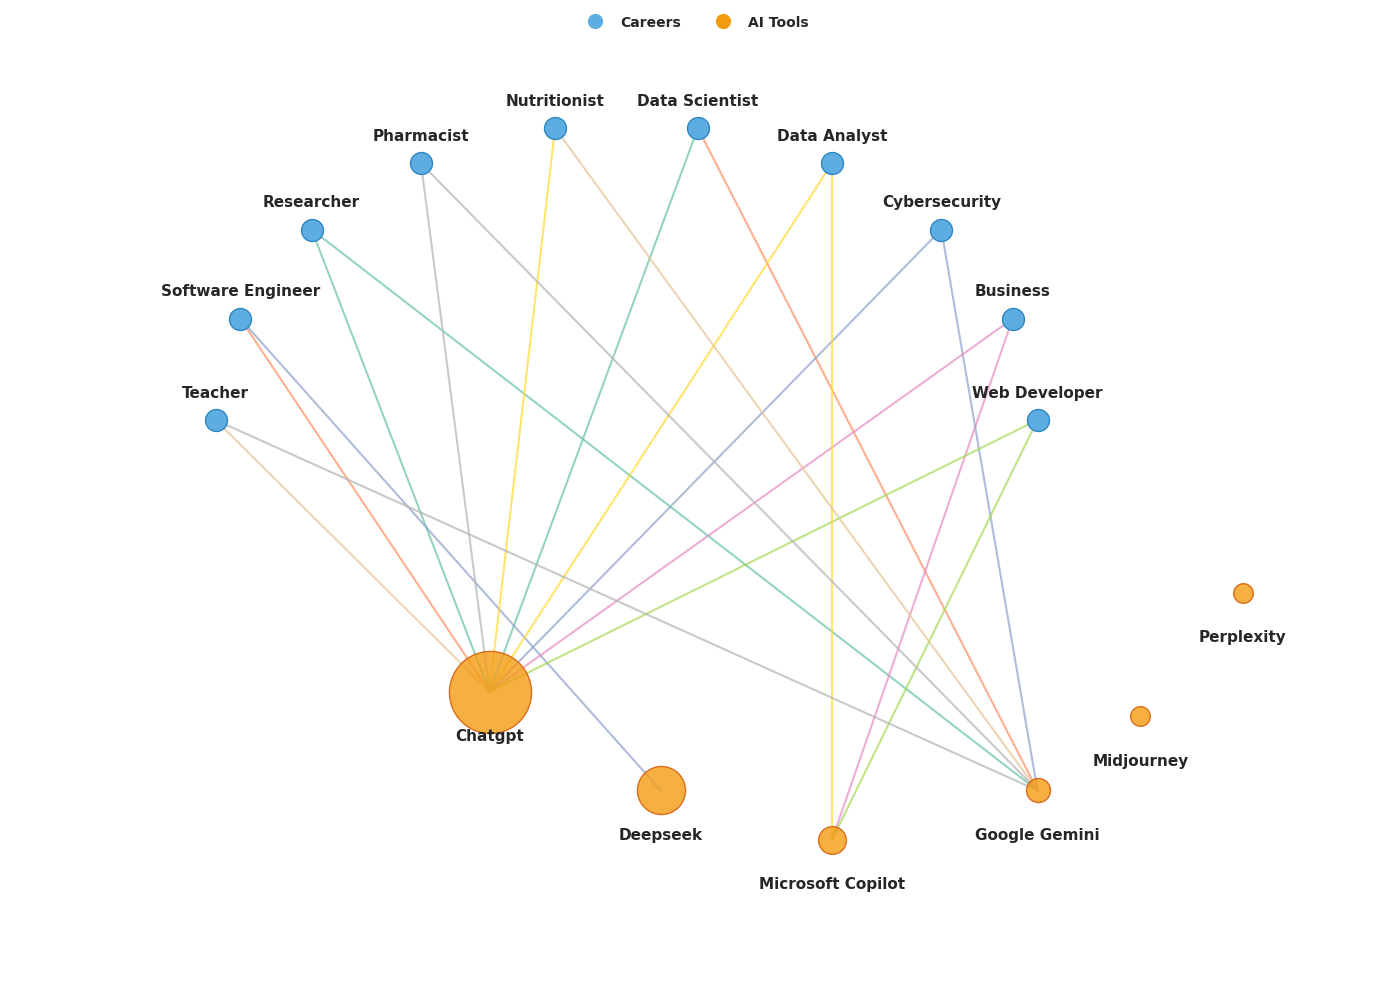

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Data Cleaning & Mapping ---
# Standardize Career paths (reusing logic to match your sample labels)
def categorize_career(path):
    path = str(path).lower()
    if 'nutritionist' in path: return 'Nutritionist'
    if 'data scientist' in path: return 'Data Scientist'
    if 'analyst' in path: return 'Data Analyst'
    if any(x in path for x in ['business', 'entrepreneur', 'banker', 'accountant']): return 'Business'
    if any(x in path for x in ['cyber', 'security', 'hacker']): return 'Cybersecurity'
    if 'pharmacist' in path: return 'Pharmacist'
    if 'web' in path: return 'Web Developer'
    if any(x in path for x in ['teacher', 'lecturer', 'professor']): return 'Teacher'
    if 'researcher' in path or 'research' in path: return 'Researcher'
    if any(x in path for x in ['software', 'developer', 'programmer']): return 'Software Engineer'
    return None

# Clean Tool names
def clean_tool(tool):
    t = str(tool).strip().lower()
    if 'chatgpt' in t: return 'Chatgpt'
    if 'deepseek' in t: return 'Deepseek'
    if 'copilot' in t: return 'Microsoft Copilot'
    if 'gemini' in t: return 'Google Gemini'
    if 'midjourney' in t: return 'Midjourney'
    if 'perplexity' in t: return 'Perplexity'
    return None

df['career_group'] = df['career_path'].apply(categorize_career)
df['threat_tool'] = df['ai_tool_perception'].apply(clean_tool)

# Filter data and find TOP 2 tools per career
links_raw = df.dropna(subset=['career_group', 'threat_tool'])
top_links = []
for career in links_raw['career_group'].unique():
    subset = links_raw[links_raw['career_group'] == career]
    top_2 = subset['threat_tool'].value_counts().nlargest(2).index.tolist()
    for tool in top_2:
        top_links.append({'career': career, 'tool': tool})

links_df = pd.DataFrame(top_links)

# --- 2. Node Positioning (Circular Arc Layout) ---
careers = ['Teacher', 'Software Engineer', 'Researcher', 'Pharmacist', 'Nutritionist', 
           'Data Scientist', 'Data Analyst', 'Cybersecurity', 'Business', 'Web Developer']
tools = ['Chatgpt', 'Deepseek', 'Microsoft Copilot', 'Google Gemini', 'Midjourney', 'Perplexity']

pos = {}
# Positioning Careers on the upper semi-circle
for i, name in enumerate(careers):
    angle = np.pi - (i / (len(careers)-1)) * np.pi
    pos[name] = (np.cos(angle) * 1.2, np.sin(angle) * 1.2 + 0.5)

# Positioning Tools on the lower area
for i, name in enumerate(tools):
    x_offset = -1.0 + (i * 0.4)
    pos[name] = (x_offset, -0.8 if i % 2 == 0 else -1.0)

# Manually tweak Chatgpt and Deepseek to be central and prominent
pos['Chatgpt'] = (-0.4, -0.6)
pos['Deepseek'] = (0.1, -1.0)
pos['Microsoft Copilot'] = (0.6, -1.2)
pos['Google Gemini'] = (1.2, -1.0)
pos['Midjourney'] = (1.5, -0.7)
pos['Perplexity'] = (1.8, -0.2)

# --- 3. Plotting ---
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Draw Connection Lines with unique colors
edge_colors = plt.cm.Set2(np.linspace(0, 1, len(links_df)))
for i, row in links_df.iterrows():
    if row['career'] in pos and row['tool'] in pos:
        p1 = pos[row['career']]
        p2 = pos[row['tool']]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=edge_colors[i], alpha=0.7, linewidth=1.5, zorder=1)

# Draw Career Nodes (Blue)
for name in careers:
    p = pos[name]
    ax.scatter(p[0], p[1], s=250, color='#5DADE2', edgecolors='#2E86C1', zorder=3)
    ax.text(p[0], p[1] + 0.08, name, fontsize=11, fontweight='bold', ha='center', va='bottom')

# Draw Tool Nodes (Orange) with specific sizing
tool_sizes = {'Chatgpt': 3500, 'Deepseek': 1200, 'Microsoft Copilot': 400, 
              'Google Gemini': 300, 'Midjourney': 200, 'Perplexity': 200}

for name in tools:
    p = pos[name]
    size = tool_sizes.get(name, 300)
    ax.scatter(p[0], p[1], s=size, color='#F39C12', edgecolors='#D35400', alpha=0.8, zorder=3)
    ax.text(p[0], p[1] - 0.15, name, fontsize=11, fontweight='bold', ha='center', va='top')

# Legend at top
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Careers', markerfacecolor='#5DADE2', markersize=12),
                   Line2D([0], [0], marker='o', color='w', label='AI Tools', markerfacecolor='#F39C12', markersize=12)]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, frameon=False, prop={'weight':'bold'})



plt.axis('off')
plt.xlim(-1.8, 2.2)
plt.ylim(-1.8, 2.0)
plt.tight_layout()
plt.show()